<a href="https://colab.research.google.com/github/PeesapatiRohithSharma/Summer_2026/blob/main/GMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
import math

In [ ]:
data = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
df = pd.read_csv('Iris.csv')

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
y = df['Species']

In [ ]:
y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [ ]:
set(y)

{'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

In [ ]:
X = df.iloc[:, 1:5]

In [ ]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y = y.map({'Iris-setosa':1, 'Iris-versicolor':2, 'Iris-virginica':3})

In [ ]:
y

,Species
0,1
1,1
2,1
3,1
4,1
...,...
145,3
146,3
147,3
148,3


In [ ]:
colours = {1:'red', 2:'blue', 3:'green'}

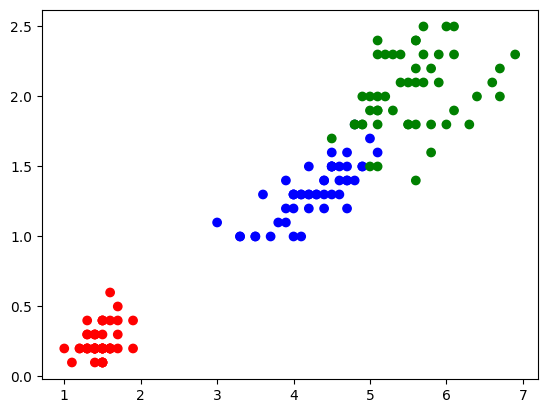

In [ ]:
plt.scatter(X['PetalLengthCm'],X['PetalWidthCm'], c = y.map(colours))
plt.show()

In [ ]:
class GMM:
  def __init__(self, X, n):
    self.X = X
    self.n = n

    self.phi = np.ones(n)/n

    self.Q = np.zeros((self.X.shape[0], self.n))

    np.random.seed(123)
    random = np.random.choice(self.X.shape[0], self.n, replace=False)
    self.mu = self.X[random]

    self.covariance = [np.eye(self.X.shape[1]) for _ in range(self.n)]

  def guassian(self,x, mu, sigma):
    diff = (x - mu)
    sigma_inv = np.linalg.inv(sigma)
    power = float(-0.5*(diff.T@sigma_inv@diff))
    coefficient = 1/((np.sqrt(2 * np.pi) ** 2) * np.sqrt(np.linalg.det(sigma)))
    return coefficient * np.exp(power)

  def E_step(self):
    for i in range(self.X.shape[0]):
      probs = []
      for j in range(self.n):
        prob = (self.phi[j]) * (self.guassian(self.X[i], self.mu[j], self.covariance[j]))
        probs.append(prob)
      probs = np.array(probs)
      self.Q[i] = probs/np.sum(probs)

  def M_step(self):
    eff_num = np.sum(self.Q, axis = 0)
    for j in range(self.n):
      self.phi[j] = (1/self.X.shape[0])*(eff_num[j])
      self.mu[j] = (self.Q[:, j] @ self.X).sum(axis=0)/eff_num[j]
      diff = self.X - self.mu[j]
      self.covariance[j] = ((self.Q[:, j][:,None]* diff).T @ diff) / eff_num[j]

  def fit(self,iteration=500):
    for _ in range(iteration):
      self.E_step()
      self.M_step()
  def predict(self):
    return np.argmax(self.Q, axis=1)


In [ ]:
model = GMM(X.to_numpy(),3)
model.fit(200)
labels = model.predict()

In [ ]:
labels+1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 3, 2, 2, 2,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])

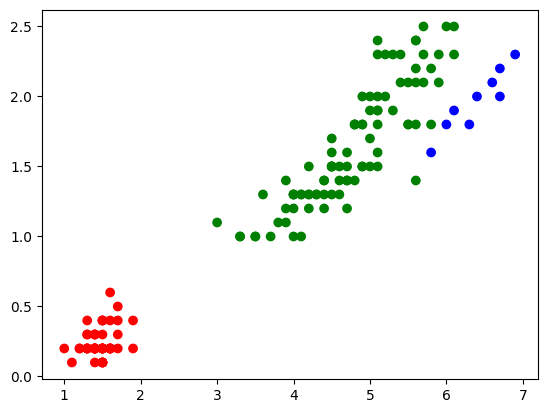

In [ ]:
plt.scatter(X['PetalLengthCm'],X['PetalWidthCm'], c = [colours[l] for l in labels+1])

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5181750620368553
